### ASSIGNMENT No: 11 

Title: For an image classification challenge, create and train a ConvNet in Python using TensorFlow. 

Also, try to improve the performance of the model by applying various hyper parameter tuning to reduce the overfitting or under fitting problem that might occur. Maintain graphs of comparisons.

Problem Statement:  Implement an image classification challenge, create and train a ConvNet in Python using TensorFlow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize data (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [3]:
def create_model(filters=32, dropout_rate=0.0):
    model = models.Sequential([
        layers.Conv2D(filters, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        
        layers.Dropout(dropout_rate),  # helps reduce overfitting
        
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [4]:
model1 = create_model(filters=32, dropout_rate=0.0)

history1 = model1.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4508 - loss: 1.5215 - val_accuracy: 0.5542 - val_loss: 1.2418
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5832 - loss: 1.1875 - val_accuracy: 0.6084 - val_loss: 1.1319
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6333 - loss: 1.0554 - val_accuracy: 0.6356 - val_loss: 1.0524
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6593 - loss: 0.9793 - val_accuracy: 0.6546 - val_loss: 0.9866
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6824 - loss: 0.9119 - val_accuracy: 0.6756 - val_loss: 0.9423


In [5]:
model2 = create_model(filters=32, dropout_rate=0.5)

history2 = model2.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3049 - loss: 1.8576 - val_accuracy: 0.4524 - val_loss: 1.5752
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4114 - loss: 1.5949 - val_accuracy: 0.5354 - val_loss: 1.3667
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4710 - loss: 1.4490 - val_accuracy: 0.5752 - val_loss: 1.1873
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5148 - loss: 1.3430 - val_accuracy: 0.6166 - val_loss: 1.0952
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5465 - loss: 1.2627 - val_accuracy: 0.6366 - val_loss: 1.0739


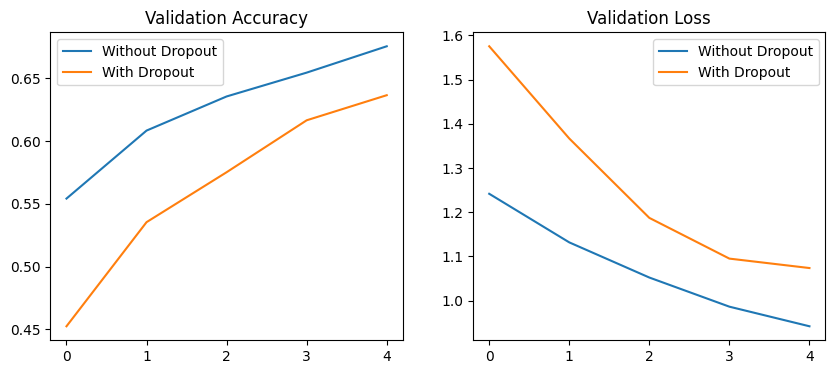

In [6]:
plt.figure(figsize=(10,4))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(history1.history['val_accuracy'], label='Without Dropout')
plt.plot(history2.history['val_accuracy'], label='With Dropout')
plt.title("Validation Accuracy")
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history1.history['val_loss'], label='Without Dropout')
plt.plot(history2.history['val_loss'], label='With Dropout')
plt.title("Validation Loss")
plt.legend()

plt.show()

In [7]:
loss, acc = model2.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6243 - loss: 1.0943
Test Accuracy: 0.6243000030517578


In [8]:
import cv2

# Load image (put image.jpg in same folder)
img = cv2.imread("image.jpg")

# Resize to CIFAR-10 size (32x32)
img = cv2.resize(img, (32, 32))

# Convert BGR → RGB (important for correct colors)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Normalize (same as training)
img = img / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
prediction = model2.predict(img)

# Class names
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# Get predicted class
pred_class = class_names[np.argmax(prediction)]

print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Class: Truck


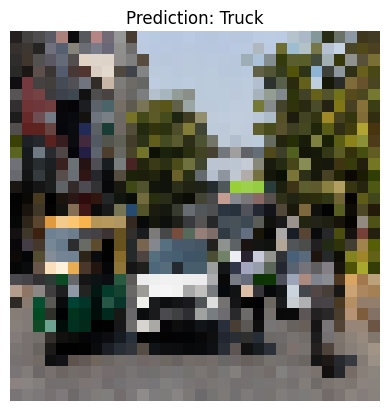

In [9]:
plt.imshow(img[0])
plt.title(f"Prediction: {pred_class}")
plt.axis('off')
plt.show()